# H3 Zone Assignment and analysis 

**Purpose:** Assign every cleaned quote to an H3 hexagonal zone, filter sparse zones,
and explore demand & conversion patterns by hour of day and day of week.

**Output:** `data/processed/quotes_hourly_h3.parquet`


**What is important for you in this notebook:**

- All analysis is based on quotes grouped by their **pickup location**. Going forward, demand will be defined as the number of quotes per zone multiplied by the conversion rate.

- Identification of zones with sufficient data (see points #2 and #3). An 85% threshold (share of hours in the time series with more than 0 quotes) was chosen manually to ensure that central zones are not excluded for analysis.

- CV heatmap (zone × hour) in point #10: zones with stable conversion rates are identified using the coefficient of variation (CV = std / mean). This helps flag zones where demand predictions may be unreliable due to high variability.

- Point #12: Top 7 zones by total quote volume, accounting for 47% of all pickup quotes.

- Point #13: Hourly quote patterns — comparison between top 7 zones and remaining zones (all days / weekdays / weekends).

- Point #14: Hourly quote patterns per-zone average — same as above, but normalized by the number of zones for direct comparability.



**All Contents**

1. Load canonical quotes, filter to bbox, assign H3 cells, aggregate to hourly demand table
2. Fill rate — compute share of observed hours per zone and drop zones below 85% threshold
3. Map — choropleth of kept (blue) vs. dropped (red) zones
4. Average quotes per zone — 24 choropleth maps, one per hour of day
5. Mean conversion rate per zone — 24 maps by hour of day
6. Std of conversion rate per zone — 24 maps by hour of day
7. Average quotes per zone — 7 maps by day of week
8. Mean conversion rate per zone — 7 maps by day of week
9. Std of conversion rate per zone — 7 maps by day of week
10. CV heatmap (zone × hour) — stability matrix and risk classification map (no risk / moderate / high)
11. Save output — write `quotes_hourly_h3.parquet` with `hour_of_day`, `day_of_week`, `cv_risk` columns
12. Top 7 zones by total quote volume — map highlighting the busiest hexagons
13. Hourly quote patterns — summed quotes for top-7 vs. remaining zones (all days / workdays / weekends)
14. Hourly quote patterns per-zone average — same as §17 divided by zone count for direct comparability

In [280]:
import sys
sys.path.insert(0, "..")

from math import ceil

import h3
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from shapely.geometry import Polygon

from src.config import QUOTES_CANONICAL_FILE, CENTER_BBOX

H3_RESOLUTION       = 7
FILL_RATE_THRESHOLD = 0.85   # drop zones present in fewer than 85 % of hours
ROADS_FILE          = "../london_roads.geojson"
OUT_PATH            = "../data/processed/quotes_hourly_h3.parquet"
DOW_LABELS          = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]

## 1. H3 zones assignement
Threshold of 85% was chosen manually to ensure that central zones are not excluded from the dataset.

In [281]:
# Load canonical quotes (deduplicated — one row per quote_id)
quotes = pd.read_parquet(QUOTES_CANONICAL_FILE)
print(f"Loaded {len(quotes):,} quotes")

# Filter to central London bounding box
minx, miny, maxx, maxy = CENTER_BBOX
quotes = quotes[
    quotes["pickup_longitude"].between(minx, maxx) &
    quotes["pickup_latitude"].between(miny, maxy)
].reset_index(drop=True)
print(f"After bbox filter : {len(quotes):,} quotes")

# Assign each pickup to an H3 cell
quotes["h3_zone"] = [
    h3.latlng_to_cell(lat, lon, H3_RESOLUTION)
    for lat, lon in zip(quotes["pickup_latitude"], quotes["pickup_longitude"])
]
print(f"Unique H3 zones   : {quotes['h3_zone'].nunique()}")

# Floor each quote to its hour bucket, then aggregate to (zone, hour) level
quotes["hour_bucket"] = quotes["quote_creation_timestamp"].dt.floor("h")
hourly = (
    quotes.groupby(["h3_zone", "hour_bucket"])
    .agg(quote_count=("quote_id", "nunique"),
         trip_count=("quote_converted", "sum"))
    .reset_index()
)
hourly["conversion_rate"] = hourly["trip_count"] / hourly["quote_count"].clip(lower=1)
print(f"Hourly rows       : {len(hourly):,}")
hourly.head()

Loaded 511,796 quotes
After bbox filter : 511,700 quotes
Unique H3 zones   : 58
Hourly rows       : 35,286


,h3_zone,hour_bucket,quote_count,trip_count,conversion_rate
0,87194ad00ffffff,2026-03-01 00:00:00+00:00,4,0,0.000000
1,87194ad00ffffff,2026-03-01 01:00:00+00:00,7,2,0.285714
2,87194ad00ffffff,2026-03-01 02:00:00+00:00,1,0,0.000000
3,87194ad00ffffff,2026-03-01 09:00:00+00:00,2,2,1.000000
4,87194ad00ffffff,2026-03-01 11:00:00+00:00,2,1,0.500000


## 2. Fill rate — identify and drop sparse zones

A zone’s **fill rate** is the share of the total observed hours in which it has any data.
Zones below the threshold lack enough time slots to produce a reliable hourly forecast.

Total hour buckets : 744
Threshold          : 85%
Zones to DROP      : 23 / 58
Zones to KEEP      : 35 / 58


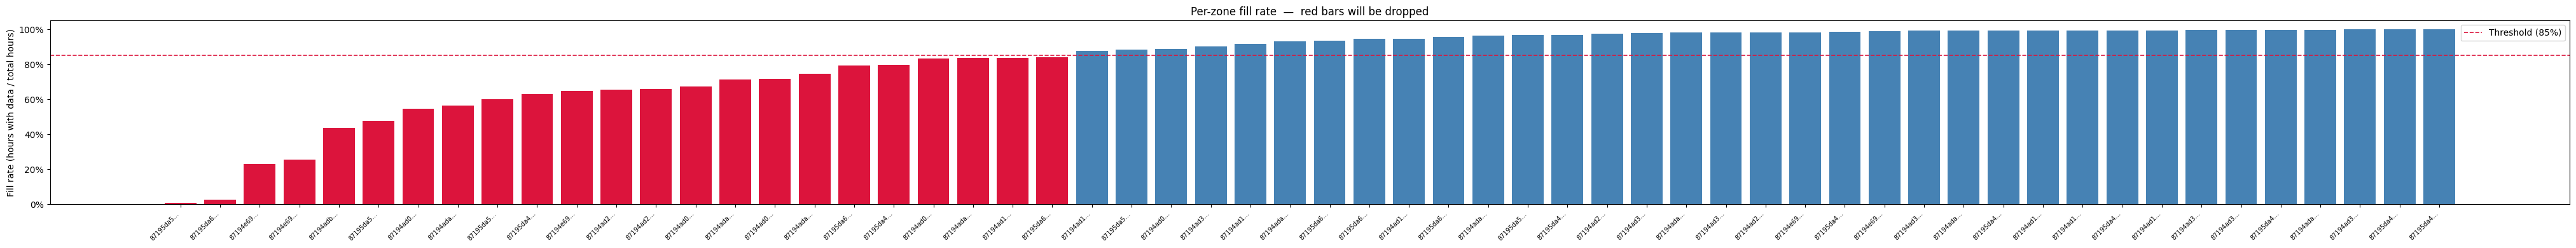

In [282]:
n_zones = hourly["h3_zone"].nunique()
n_hours = hourly["hour_bucket"].nunique()

zone_fill = (
    hourly.groupby("h3_zone")["hour_bucket"]
    .count()
    .rename("hours_observed")
    .reset_index()
)
zone_fill["fill_rate"] = zone_fill["hours_observed"] / n_hours
zone_fill = zone_fill.sort_values("fill_rate").reset_index(drop=True)
zone_fill["drop"] = zone_fill["fill_rate"] < FILL_RATE_THRESHOLD

zones_to_drop = zone_fill.loc[zone_fill["drop"],  "h3_zone"].tolist()
zones_to_keep = zone_fill.loc[~zone_fill["drop"], "h3_zone"].tolist()

print(f"Total hour buckets : {n_hours}")
print(f"Threshold          : {FILL_RATE_THRESHOLD:.0%}")
print(f"Zones to DROP      : {len(zones_to_drop)} / {n_zones}")
print(f"Zones to KEEP      : {len(zones_to_keep)} / {n_zones}")

fig, ax = plt.subplots(figsize=(max(8, n_zones * 0.7), 4))
colors = ["crimson" if d else "steelblue" for d in zone_fill["drop"]]
ax.bar(range(n_zones), zone_fill["fill_rate"], color=colors, width=0.8)
ax.axhline(FILL_RATE_THRESHOLD, color="crimson", linestyle="--", linewidth=1.2,
           label=f"Threshold ({FILL_RATE_THRESHOLD:.0%})")
ax.set_xticks(range(n_zones))
ax.set_xticklabels([z[:8] + "…" for z in zone_fill["h3_zone"]],
                   rotation=45, ha="right", fontsize=7)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.set_ylabel("Fill rate (hours with data / total hours)")
ax.set_title("Per-zone fill rate  —  red bars will be dropped")
ax.legend()
plt.tight_layout()
plt.show()

## 3. Map — kept vs. dropped zones

/var/folders/cn/hl5lj7gd17bft8_srrs_2zvr0000gn/T/ipykernel_25272/3479564898.py:26: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend(loc="lower right", fontsize=9)
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


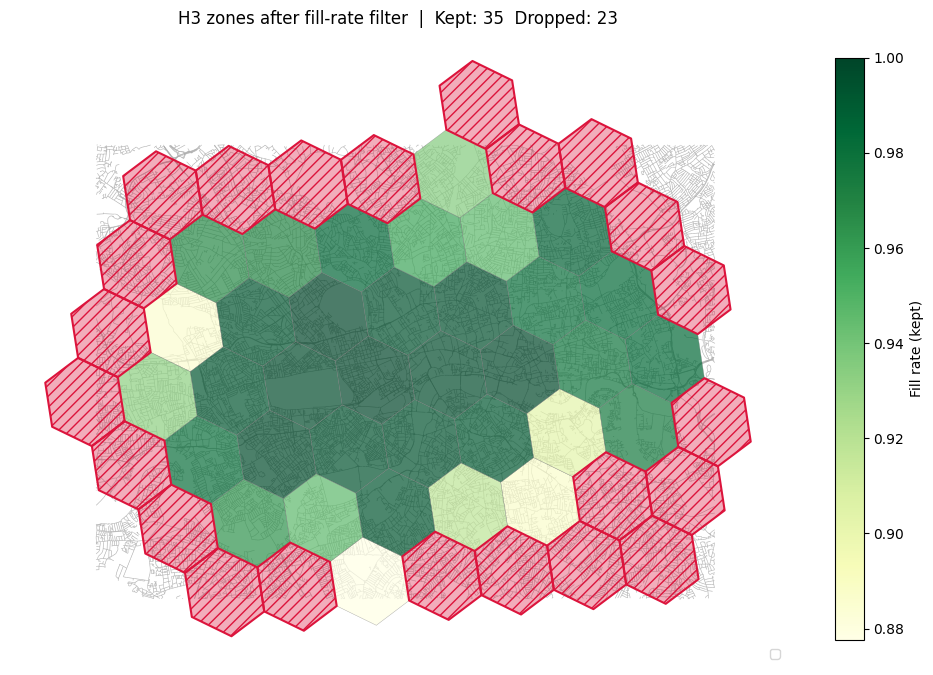

In [283]:
def h3_to_polygon(cell):
    coords = h3.cell_to_boundary(cell)
    return Polygon([(lon, lat) for lat, lon in coords])

all_zones = zone_fill.copy()
all_zones["geometry"] = all_zones["h3_zone"].apply(h3_to_polygon)
all_zones_gdf = gpd.GeoDataFrame(all_zones, geometry="geometry", crs="EPSG:4326")

kept_gdf    = all_zones_gdf[~all_zones_gdf["drop"]]
dropped_gdf = all_zones_gdf[ all_zones_gdf["drop"]]

roads_gdf = gpd.read_file(ROADS_FILE).to_crs("EPSG:4326")
bbox = all_zones_gdf.total_bounds
roads_gdf = roads_gdf.cx[bbox[0]:bbox[2], bbox[1]:bbox[3]]

fig, ax = plt.subplots(figsize=(10, 10))
roads_gdf.plot(ax=ax, color="#aaaaaa", linewidth=0.4, zorder=1)
kept_gdf.plot(column="fill_rate", cmap="YlGn", alpha=0.7, legend=True,
              legend_kwds={"label": "Fill rate (kept)", "shrink": 0.6},
              ax=ax, edgecolor="grey", linewidth=0.3, zorder=2)
if not dropped_gdf.empty:
    dropped_gdf.plot(ax=ax, color="crimson", alpha=0.35, zorder=3)
    dropped_gdf.plot(ax=ax, facecolor="none", edgecolor="crimson",
                     linewidth=1.5, hatch="///", zorder=3,
                     label=f"Dropped ({len(dropped_gdf)})")
    ax.legend(loc="lower right", fontsize=9)
ax.set_title(f"H3 zones after fill-rate filter  |  Kept: {len(kept_gdf)}  Dropped: {len(dropped_gdf)}",
             fontsize=12)
ax.set_axis_off()
plt.tight_layout()
plt.show()

## Setup — kept zones only

All maps below use only the zones that passed the fill-rate filter.

In [284]:
hourly_clean = hourly[hourly["h3_zone"].isin(zones_to_keep)].copy()
hourly_clean["hour_of_day"] = hourly_clean["hour_bucket"].dt.hour
hourly_clean["day_of_week"] = hourly_clean["hour_bucket"].dt.dayofweek  # 0=Mon

# All-days aggregations
hour_agg = (
    hourly_clean.groupby(["h3_zone", "hour_of_day"])
    .agg(mean_quotes=("quote_count",     "mean"),
         mean_cr    =("conversion_rate", "mean"),
         std_cr     =("conversion_rate", "std"))
    .reset_index()
)
hour_agg["std_cr"] = hour_agg["std_cr"].fillna(0.0)

dow_agg = (
    hourly_clean.groupby(["h3_zone", "day_of_week"])
    .agg(mean_quotes=("quote_count",     "mean"),
         mean_cr    =("conversion_rate", "mean"),
         std_cr     =("conversion_rate", "std"))
    .reset_index()
)
dow_agg["std_cr"] = dow_agg["std_cr"].fillna(0.0)

# Weekday / weekend split
is_weekday = hourly_clean["day_of_week"].between(0, 4)

hour_agg_weekday = (
    hourly_clean[is_weekday].groupby(["h3_zone", "hour_of_day"])
    .agg(mean_cr=("conversion_rate", "mean"),
         std_cr =("conversion_rate", "std"))
    .reset_index()
)
hour_agg_weekday["std_cr"] = hour_agg_weekday["std_cr"].fillna(0.0)

hour_agg_weekend = (
    hourly_clean[~is_weekday].groupby(["h3_zone", "hour_of_day"])
    .agg(mean_cr=("conversion_rate", "mean"),
         std_cr =("conversion_rate", "std"))
    .reset_index()
)
hour_agg_weekend["std_cr"] = hour_agg_weekend["std_cr"].fillna(0.0)

zones_gdf = gpd.GeoDataFrame(
    {"h3_zone": zones_to_keep},
    geometry=[h3_to_polygon(z) for z in zones_to_keep],
    crs="EPSG:4326",
)

def plot_choropleth_grid(agg_df, group_col, groups, value_col,
                         cmap, suptitle, cbar_label, group_names=None, ncols=6):
    n     = len(groups)
    nrows = ceil(n / ncols)
    vmin  = agg_df[value_col].min()
    vmax  = agg_df[value_col].max()
    fig, axes = plt.subplots(nrows, ncols,
                             figsize=(ncols * 2.6, nrows * 2.6),
                             constrained_layout=True)
    axes_flat = np.array(axes).flatten()
    for ax, g in zip(axes_flat, groups):
        subset = agg_df[agg_df[group_col] == g][["h3_zone", value_col]]
        merged = zones_gdf.merge(subset, on="h3_zone", how="left")
        merged.plot(column=value_col, cmap=cmap, ax=ax, vmin=vmin, vmax=vmax,
                    edgecolor="grey", linewidth=0.2, missing_kwds={"color": "#dddddd"})
        ax.set_title(group_names[g] if group_names else str(g), fontsize=8)
        ax.set_axis_off()
    for ax in axes_flat[n:]:
        ax.set_visible(False)
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=vmin, vmax=vmax))
    fig.colorbar(sm, ax=axes_flat[:n], shrink=0.5, label=cbar_label, pad=0.01)
    fig.suptitle(suptitle, fontsize=13)
    plt.show()

print(f"Kept zones       : {len(zones_to_keep)}")
print(f"Hour-agg rows    : {len(hour_agg)}")
print(f"Weekday-agg rows : {len(hour_agg_weekday)}  |  Weekend-agg rows : {len(hour_agg_weekend)}")

Kept zones       : 35
Hour-agg rows    : 840
Weekday-agg rows : 840  |  Weekend-agg rows : 840


## 4. Average quotes per zone — by hour of day

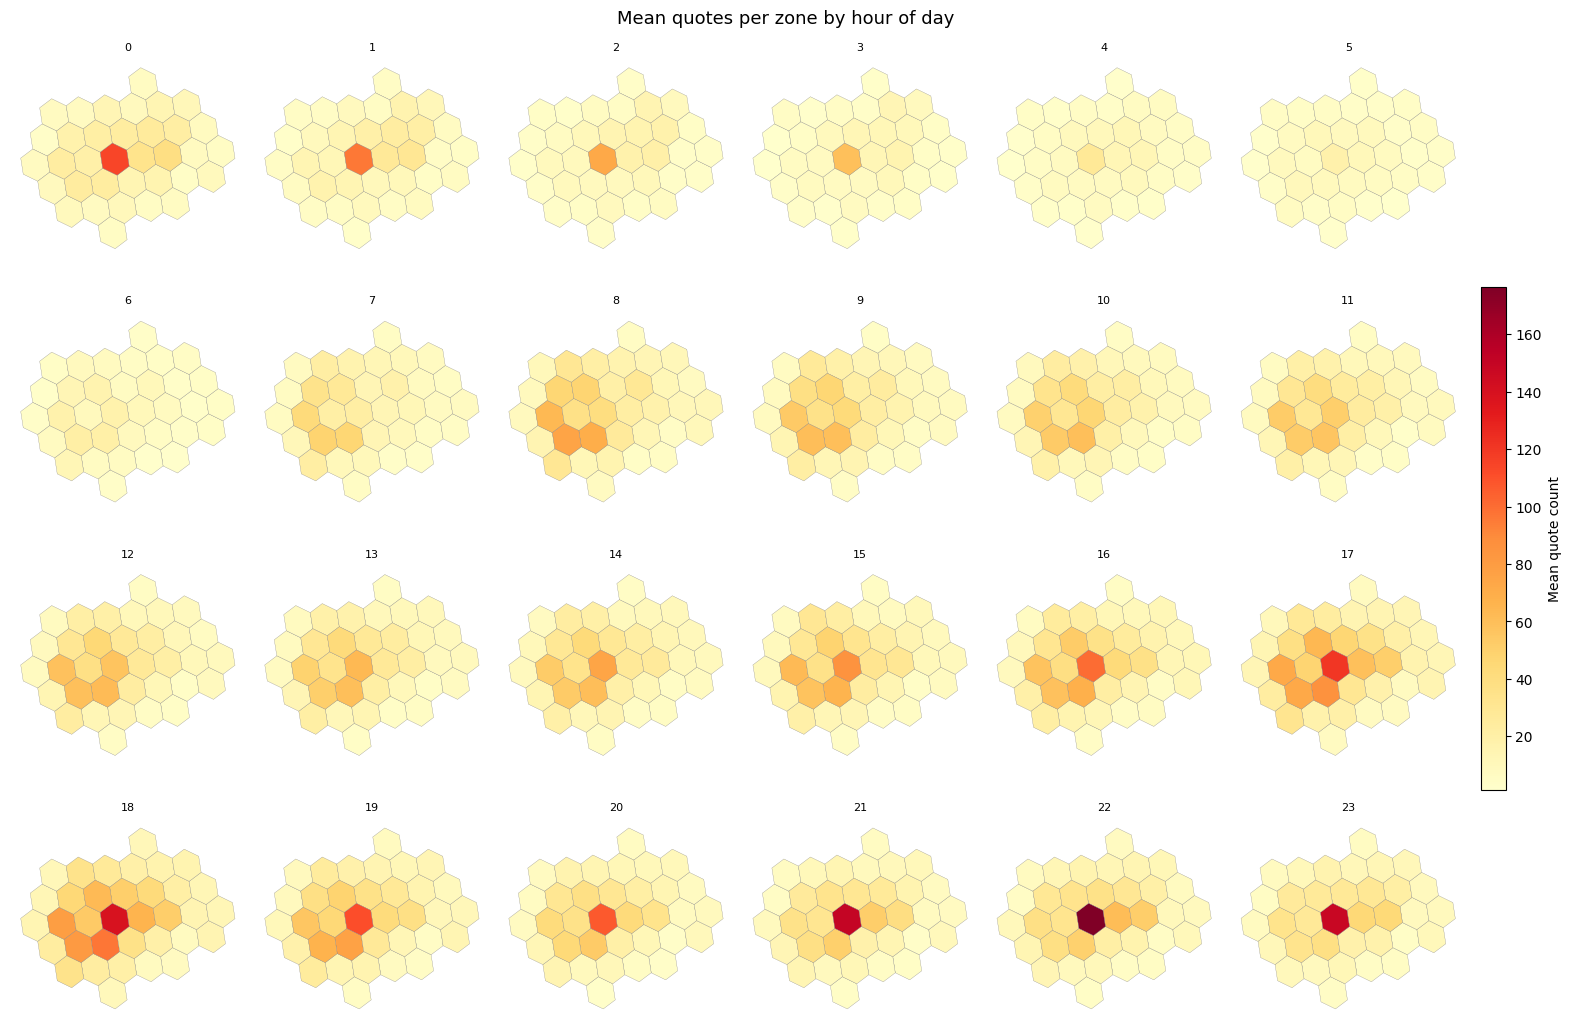

In [285]:
plot_choropleth_grid(
    agg_df=hour_agg, group_col="hour_of_day", groups=list(range(24)),
    value_col="mean_quotes", cmap="YlOrRd",
    suptitle="Mean quotes per zone by hour of day", cbar_label="Mean quote count",
)

## 5. Mean conversion rate per zone — by hour of day

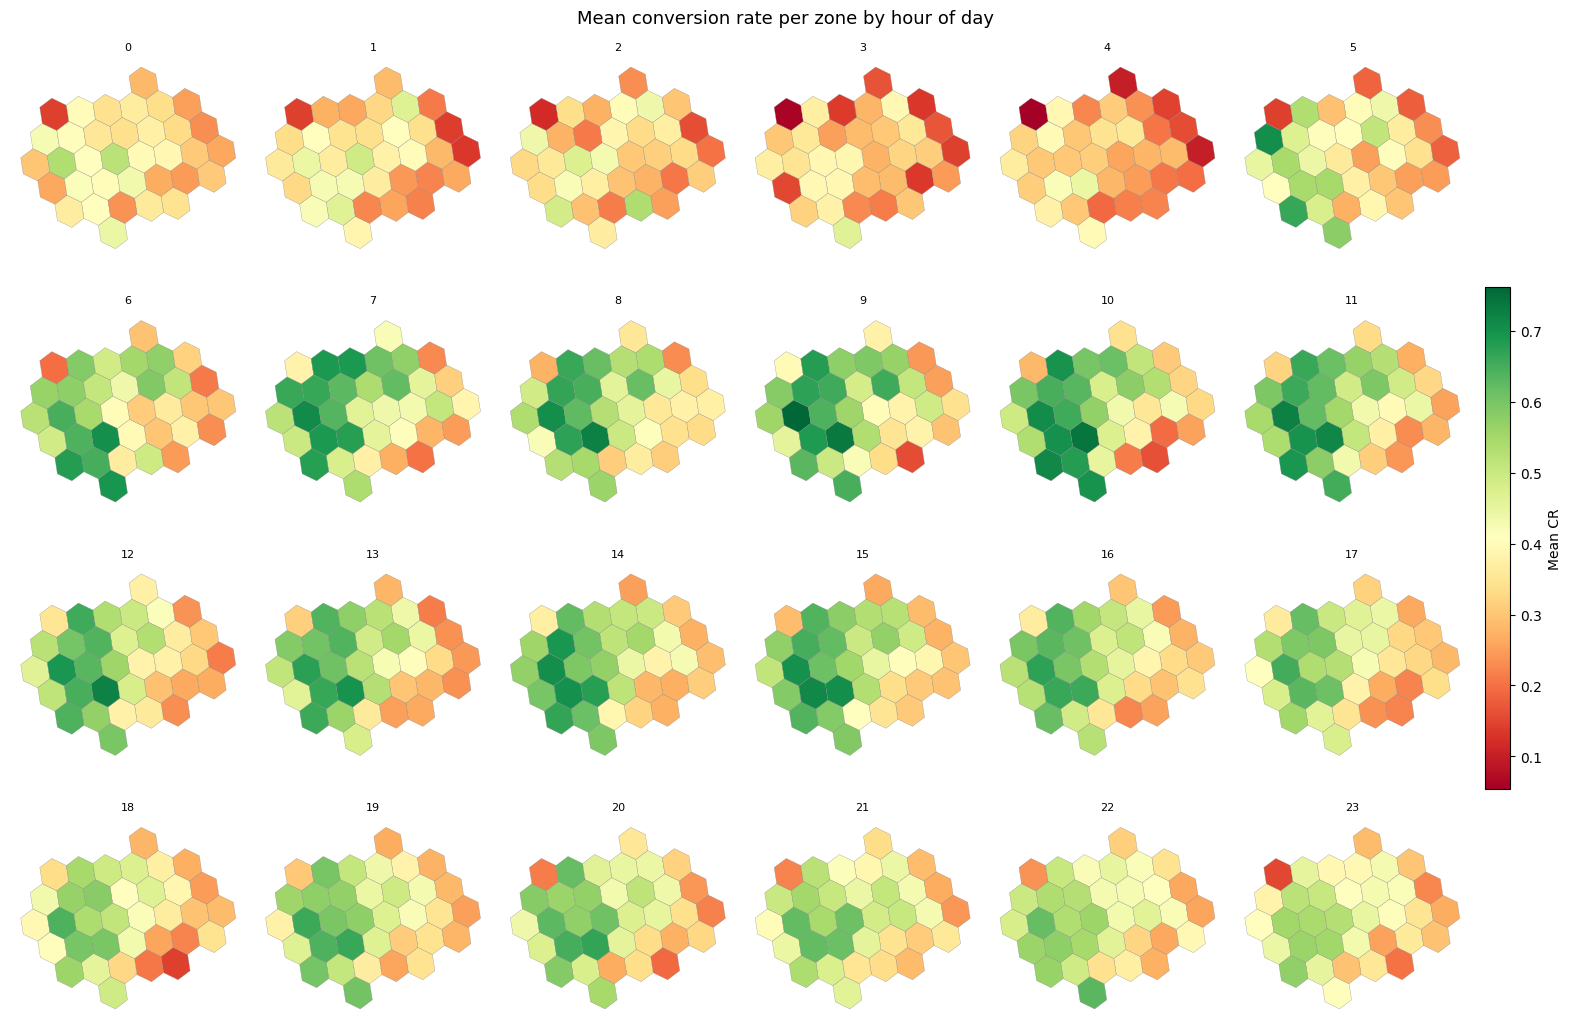

In [286]:
plot_choropleth_grid(
    agg_df=hour_agg, group_col="hour_of_day", groups=list(range(24)),
    value_col="mean_cr", cmap="RdYlGn",
    suptitle="Mean conversion rate per zone by hour of day", cbar_label="Mean CR",
)

## 6. Std of conversion rate per zone — by hour of day

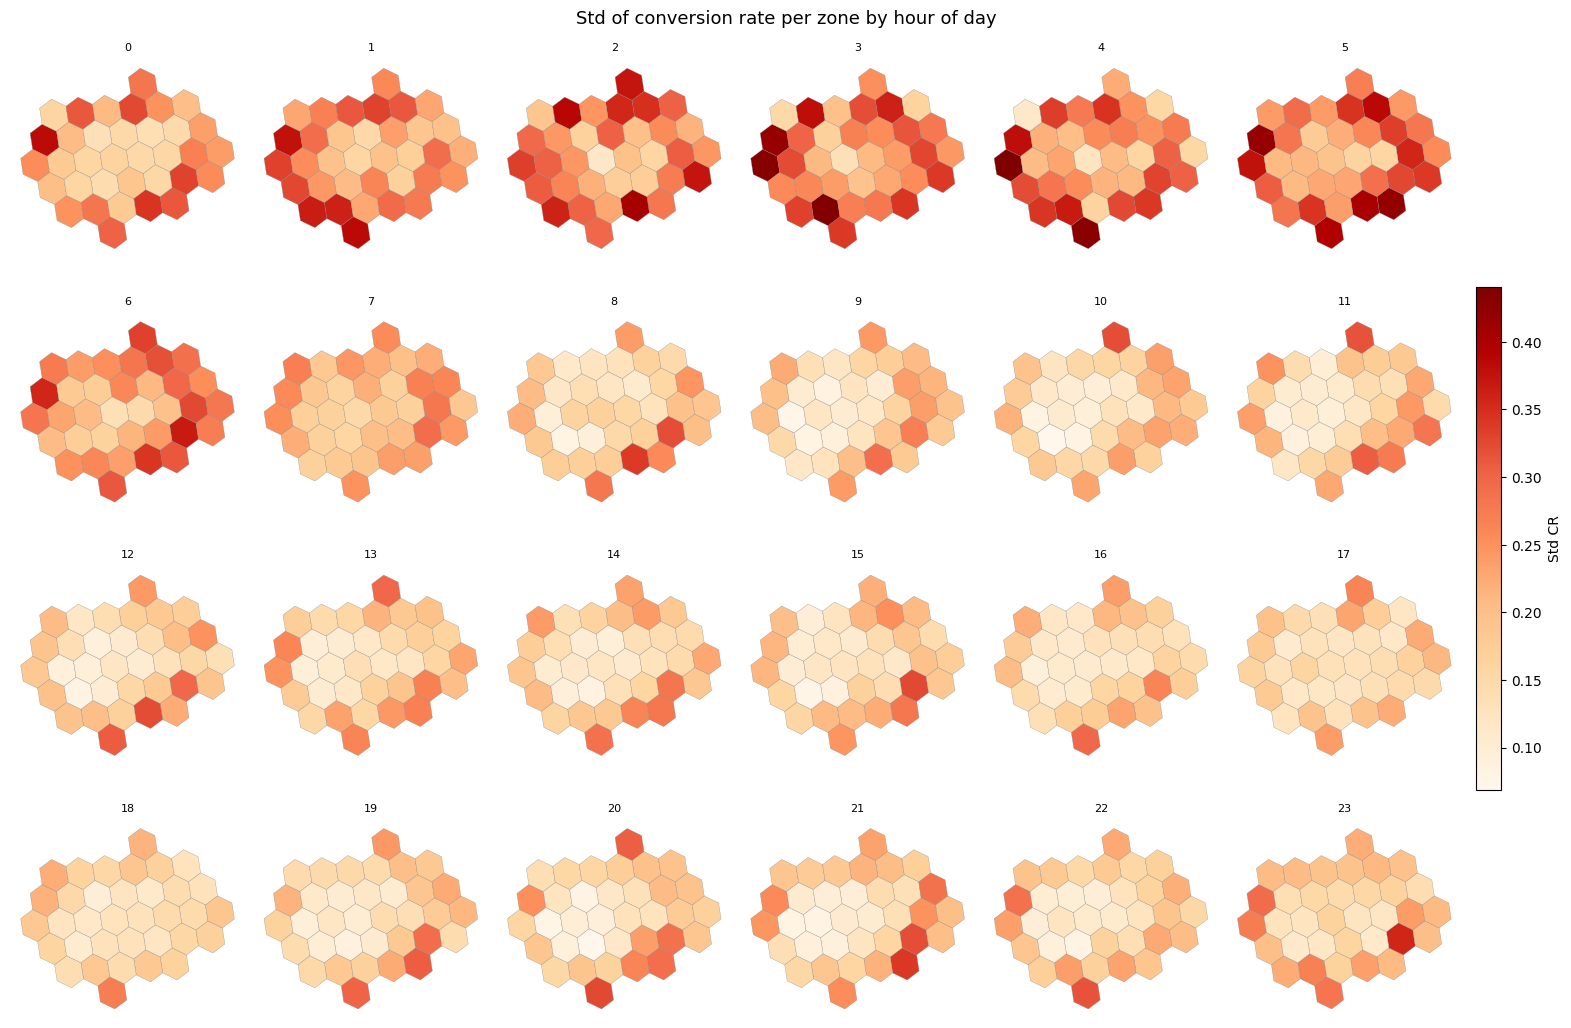

In [287]:
plot_choropleth_grid(
    agg_df=hour_agg, group_col="hour_of_day", groups=list(range(24)),
    value_col="std_cr", cmap="OrRd",
    suptitle="Std of conversion rate per zone by hour of day", cbar_label="Std CR",
)

## 7. Average quotes per zone — by day of week 

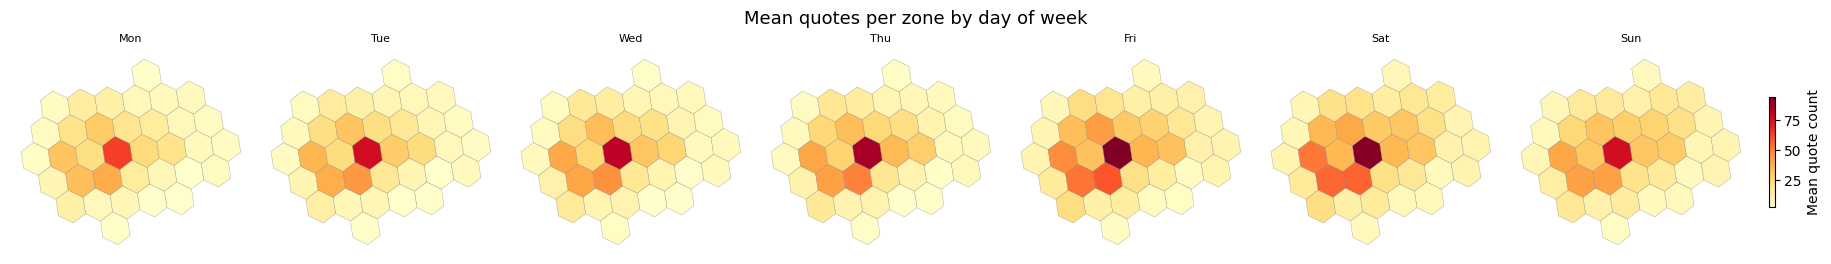

In [288]:
plot_choropleth_grid(
    agg_df=dow_agg, group_col="day_of_week", groups=list(range(7)),
    value_col="mean_quotes", cmap="YlOrRd",
    suptitle="Mean quotes per zone by day of week", cbar_label="Mean quote count",
    group_names={i: DOW_LABELS[i] for i in range(7)}, ncols=7,
)

## 8. Mean conversion rate per zone — by day of week

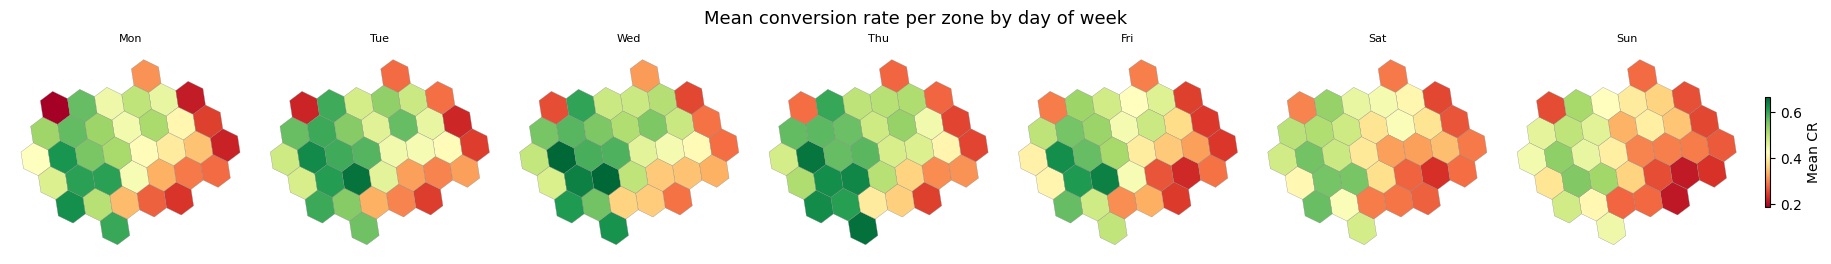

In [289]:
plot_choropleth_grid(
    agg_df=dow_agg, group_col="day_of_week", groups=list(range(7)),
    value_col="mean_cr", cmap="RdYlGn",
    suptitle="Mean conversion rate per zone by day of week", cbar_label="Mean CR",
    group_names={i: DOW_LABELS[i] for i in range(7)}, ncols=7,
)

## 9. Std of conversion rate per zone — by day of week

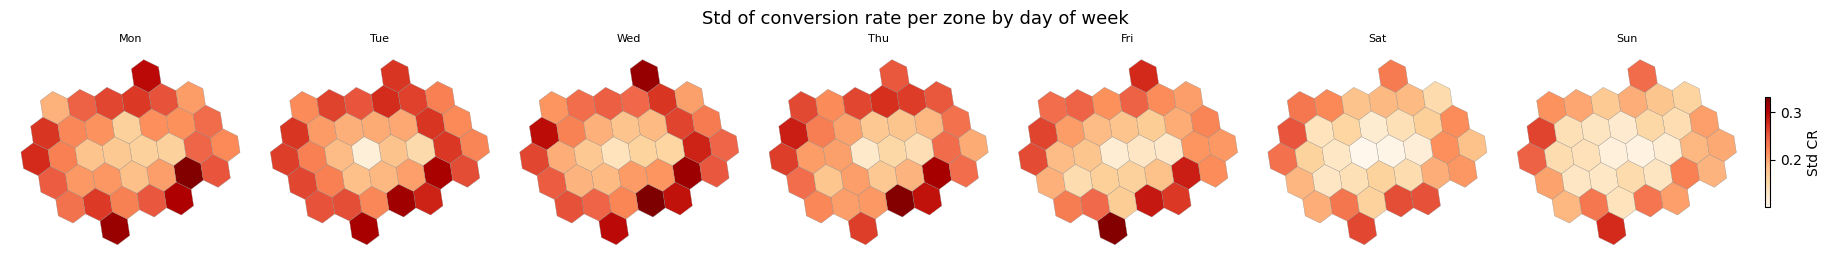

In [290]:
plot_choropleth_grid(
    agg_df=dow_agg, group_col="day_of_week", groups=list(range(7)),
    value_col="std_cr", cmap="OrRd",
    suptitle="Std of conversion rate per zone by day of week", cbar_label="Std CR",
    group_names={i: DOW_LABELS[i] for i in range(7)}, ncols=7,
)

## 10. CV heatmap — zone × hour stability

CV = std / mean per (zone, hour). Green = stable, red = volatile.

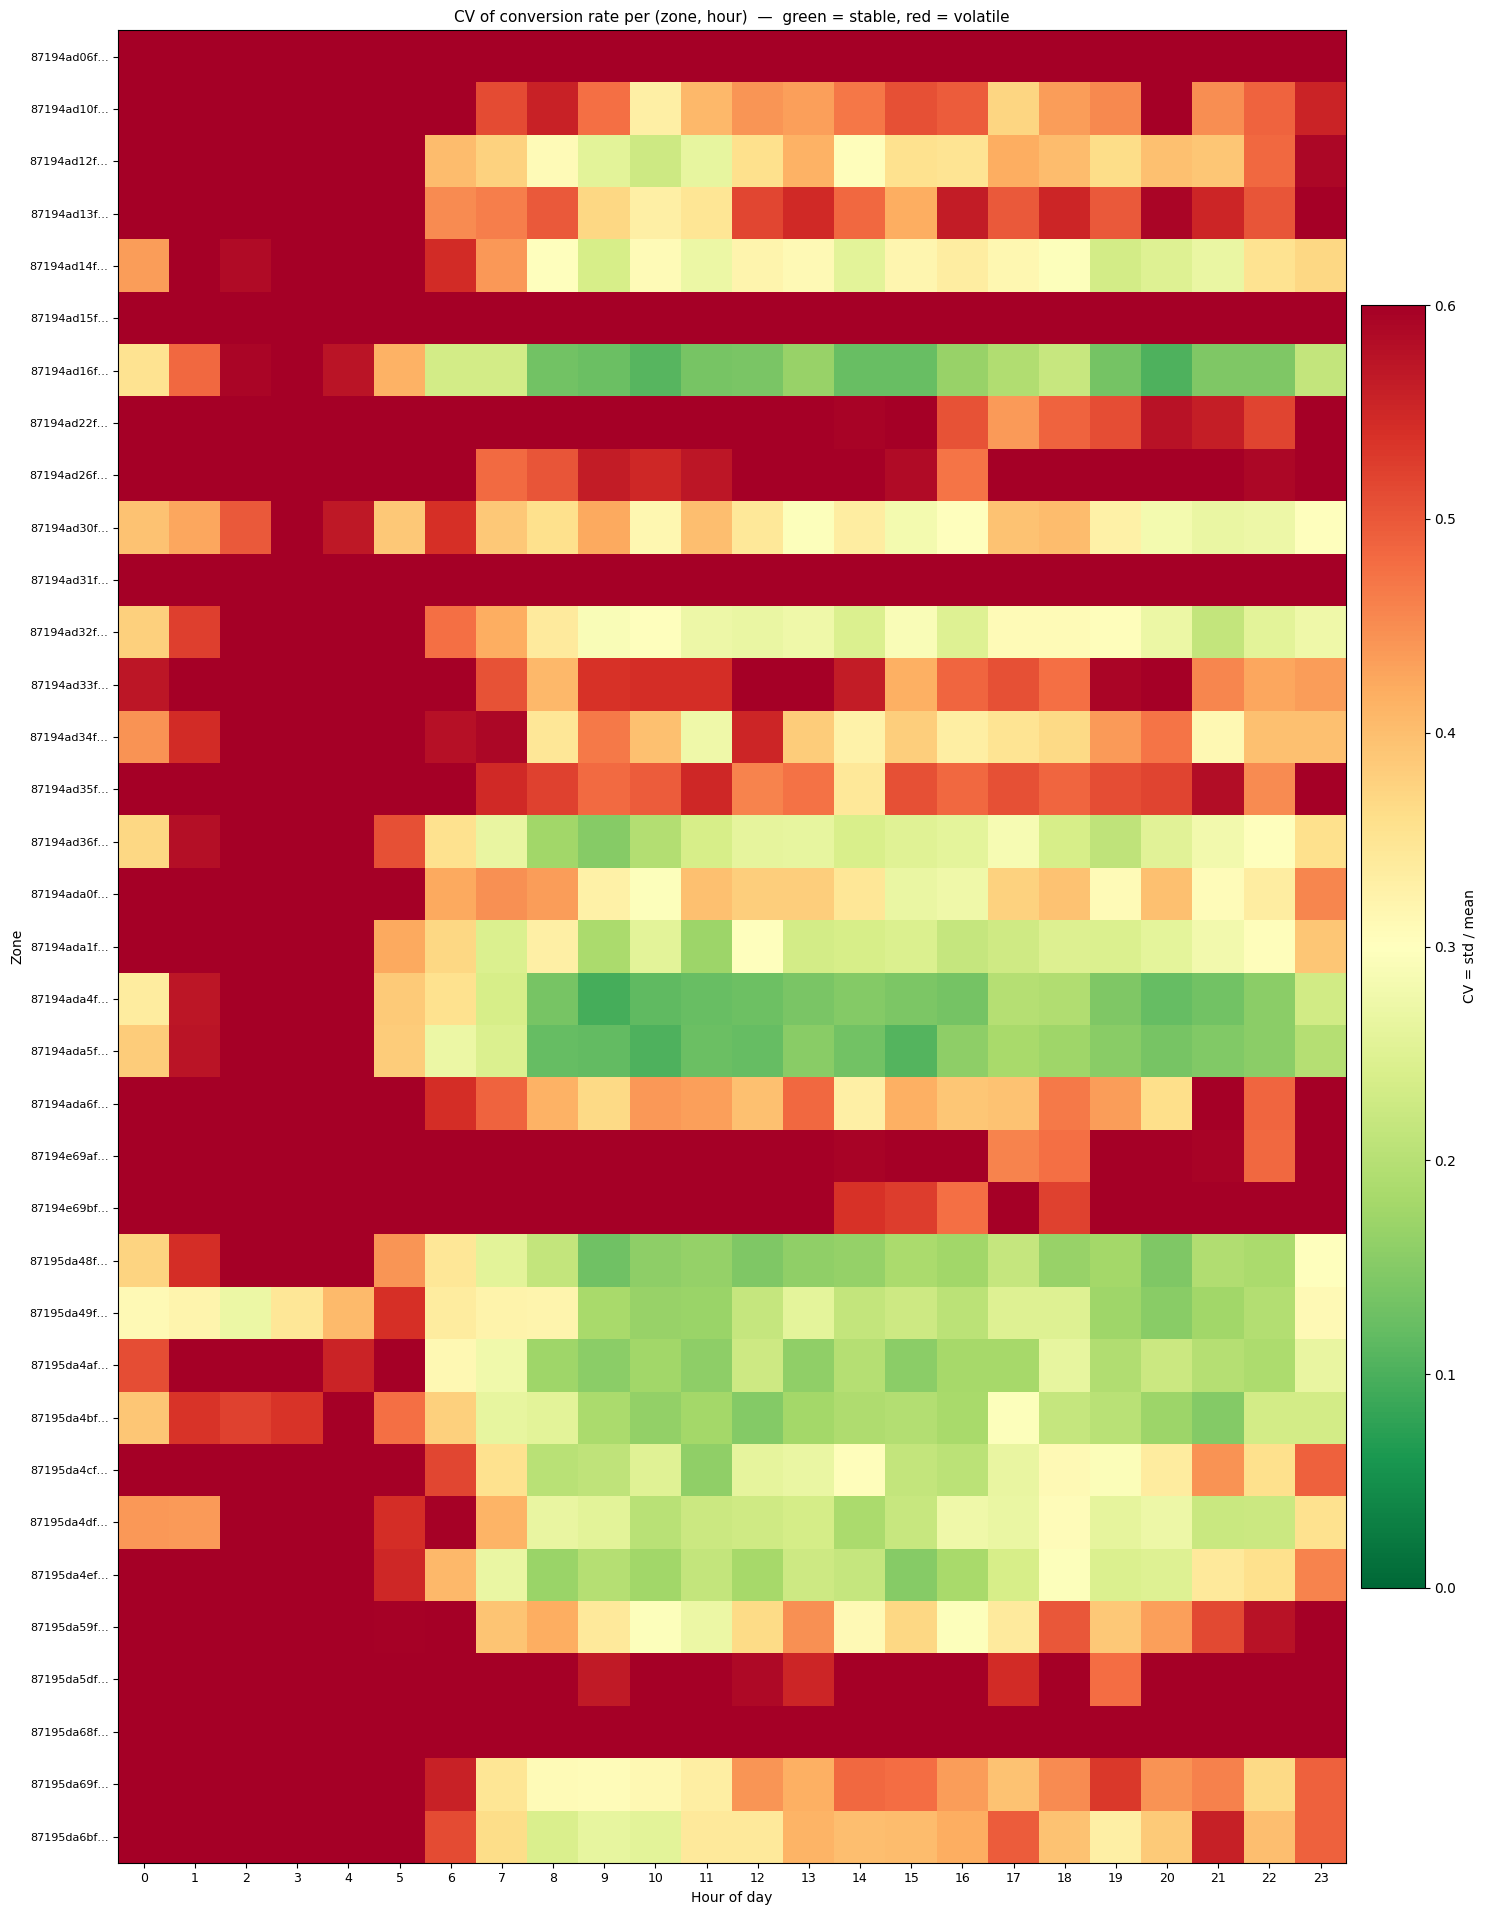

Zone risk classification (hours 08–20, thresholds: CV 0.30 / 0.50)

No risk (14 zones):
  87194ad14ffffff  mean CV = 0.288
  87194ad16ffffff  mean CV = 0.144
  87194ad32ffffff  mean CV = 0.287
  87194ad36ffffff  mean CV = 0.233
  87194ada1ffffff  mean CV = 0.243
  87194ada4ffffff  mean CV = 0.140
  87194ada5ffffff  mean CV = 0.138
  87195da48ffffff  mean CV = 0.170
  87195da49ffffff  mean CV = 0.215
  87195da4affffff  mean CV = 0.189
  87195da4bffffff  mean CV = 0.198
  87195da4cffffff  mean CV = 0.253
  87195da4dffffff  mean CV = 0.247
  87195da4effffff  mean CV = 0.212

Moderate risk (11 zones):
  87194ad10ffffff  mean CV = 0.461
  87194ad12ffffff  mean CV = 0.340
  87194ad13ffffff  mean CV = 0.478
  87194ad30ffffff  mean CV = 0.343
  87194ad34ffffff  mean CV = 0.391
  87194ad35ffffff  mean CV = 0.488
  87194ada0ffffff  mean CV = 0.352
  87194ada6ffffff  mean CV = 0.410
  87195da59ffffff  mean CV = 0.367
  87195da69ffffff  mean CV = 0.411
  87195da6bffffff  mean CV = 0.360

High risk

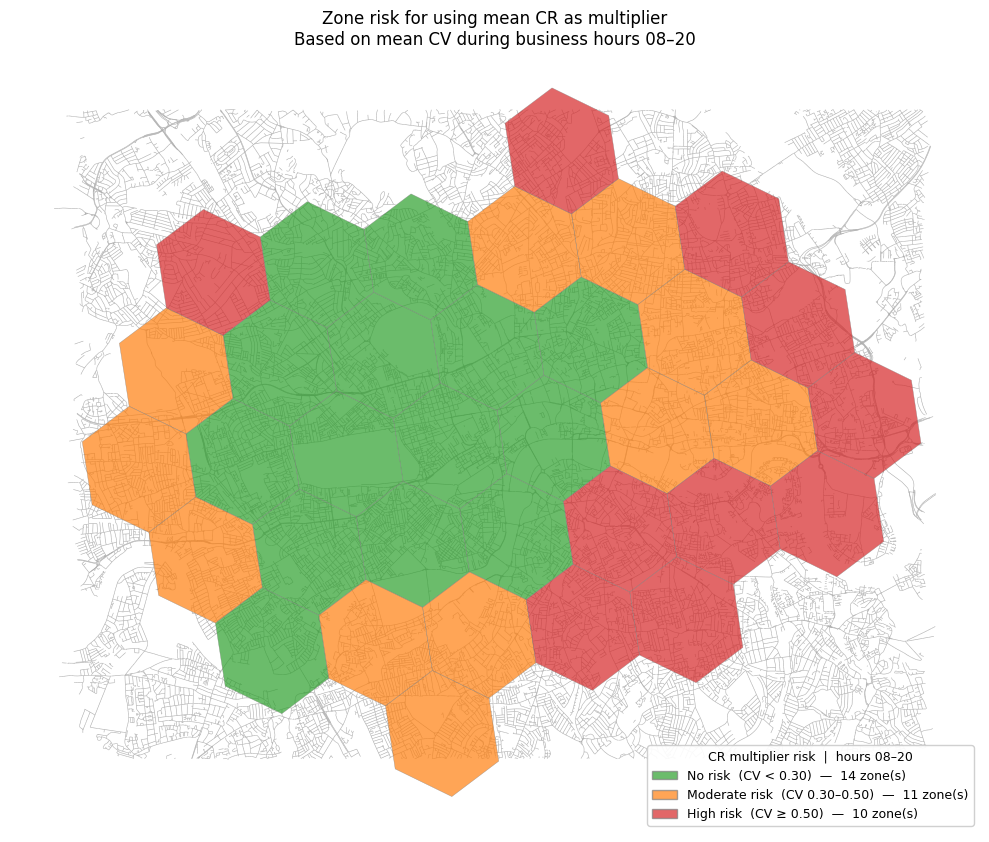

In [291]:
# CV = std / mean per (zone, hour_of_day)
cv_hour = hour_agg.copy()
cv_hour["cv"] = cv_hour["std_cr"] / cv_hour["mean_cr"].clip(lower=1e-6)

# Pivot to matrix: rows = zones, columns = hours 0-23
cv_pivot = (
    cv_hour.pivot(index="h3_zone", columns="hour_of_day", values="cv")
    .reindex(columns=range(24))
    .fillna(0.0)
)
y_labels = [z[:10] + "\u2026" for z in cv_pivot.index]

fig, ax = plt.subplots(figsize=(16, max(4, len(cv_pivot) * 0.55)))
im = ax.imshow(
    cv_pivot.values,
    aspect="auto",
    cmap="RdYlGn_r",
    vmin=0,
    vmax=0.6,
    interpolation="nearest",
)
ax.set_xticks(range(24))
ax.set_xticklabels(range(24), fontsize=9)
ax.set_yticks(range(len(y_labels)))
ax.set_yticklabels(y_labels, fontsize=8)
ax.set_xlabel("Hour of day", fontsize=10)
ax.set_ylabel("Zone", fontsize=10)
ax.set_title("CV of conversion rate per (zone, hour)  \u2014  green = stable, red = volatile",
             fontsize=11)
plt.colorbar(im, ax=ax, label="CV = std / mean", shrink=0.7, pad=0.01)
plt.tight_layout()
plt.show()

# ── Risk classification: mean CV during business hours 8-20 ───────────────────
business_cv = (
    cv_hour[cv_hour["hour_of_day"].between(8, 20)]
    .groupby("h3_zone")["cv"]
    .mean()
    .rename("mean_cv_8_20")
    .reset_index()
)

def classify_risk(cv):
    if cv < 0.30:
        return "No risk"
    elif cv < 0.50:
        return "Moderate risk"
    else:
        return "High risk"

business_cv["risk"] = business_cv["mean_cv_8_20"].apply(classify_risk)

print("Zone risk classification (hours 08\u201320, thresholds: CV 0.30 / 0.50)")
print("=" * 65)
for risk_label in ["No risk", "Moderate risk", "High risk"]:
    zones_in = business_cv[business_cv["risk"] == risk_label]
    print(f"\n{risk_label} ({len(zones_in)} zone{'s' if len(zones_in) != 1 else ''}):")
    for _, row in zones_in.iterrows():
        print(f"  {row.h3_zone}  mean CV = {row.mean_cv_8_20:.3f}")

# ── Hex map coloured by risk category ─────────────────────────────────────────
import matplotlib.patches as mpatches

RISK_COLORS = {
    "No risk":       "#2ca02c",
    "Moderate risk": "#ff7f0e",
    "High risk":     "#d62728",
}
RISK_CV_BANDS = {
    "No risk":       "CV < 0.30",
    "Moderate risk": "CV 0.30\u20130.50",
    "High risk":     "CV \u2265 0.50",
}

risk_gdf = zones_gdf.merge(business_cv, on="h3_zone", how="left")

roads_clip = gpd.read_file(ROADS_FILE).to_crs("EPSG:4326")
bb = zones_gdf.total_bounds
roads_clip = roads_clip.cx[bb[0]:bb[2], bb[1]:bb[3]]

fig, ax = plt.subplots(figsize=(10, 10))
roads_clip.plot(ax=ax, color="#aaaaaa", linewidth=0.4, zorder=1)

for risk_label, color in RISK_COLORS.items():
    subset = risk_gdf[risk_gdf["risk"] == risk_label]
    if not subset.empty:
        subset.plot(ax=ax, color=color, alpha=0.7,
                    edgecolor="grey", linewidth=0.3, zorder=2)

# Explicit Patch handles — reliable across all geopandas versions
legend_handles = [
    mpatches.Patch(
        facecolor=color,
        edgecolor="grey",
        alpha=0.7,
        label=(
            f"{label}  ({RISK_CV_BANDS[label]})"
            f"  \u2014  {len(risk_gdf[risk_gdf['risk'] == label])} zone(s)"
        ),
    )
    for label, color in RISK_COLORS.items()
]
ax.legend(
    handles=legend_handles,
    loc="lower right",
    fontsize=9,
    title="CR multiplier risk  |  hours 08\u201320",
    title_fontsize=9,
    framealpha=0.92,
)
ax.set_title(
    "Zone risk for using mean CR as multiplier\n"
    "Based on mean CV during business hours 08\u201320",
    fontsize=12,
)
ax.set_axis_off()
plt.tight_layout()
plt.show()

## 11. Save output

In [ ]:
# Map risk labels → short codes
RISK_CODES = {"No risk": "cv_30", "Moderate risk": "cv_30_50", "High risk": "cv_50"}
risk_codes = business_cv[["h3_zone", "risk"]].copy()
risk_codes["cv_risk"] = risk_codes["risk"].map(RISK_CODES)

# Merge cv_risk into hourly_clean (keep hour_of_day and day_of_week)
hourly_clean = hourly_clean.merge(risk_codes[["h3_zone", "cv_risk"]], on="h3_zone", how="left")

hourly_clean.to_parquet(OUT_PATH, index=False)


Saved → ../data/processed/quotes_hourly_h3.parquet
Shape  : (25214, 8)
Zones  : 35

CV risk distribution:
cv_risk
cv_30       14
cv_30_50    11
cv_50       10
Name: n_zones, dtype: int64

h3_zone                         object
hour_bucket        datetime64[ns, UTC]
quote_count                      int64
trip_count                       int64
conversion_rate                float64
hour_of_day                      int32
day_of_week                      int32
cv_risk                         object
dtype: object


## 12. Top 7 zones by total quote volume

Top 7 zones by total quote volume
  #1  87195da49ffffff  —  60,239 quotes
  #2  87194ad16ffffff  —  35,614 quotes
  #3  87194ada5ffffff  —  32,207 quotes
  #4  87194ada4ffffff  —  30,420 quotes
  #5  87195da48ffffff  —  25,879 quotes
  #6  87194ad32ffffff  —  23,452 quotes
  #7  87195da4bffffff  —  20,897 quotes


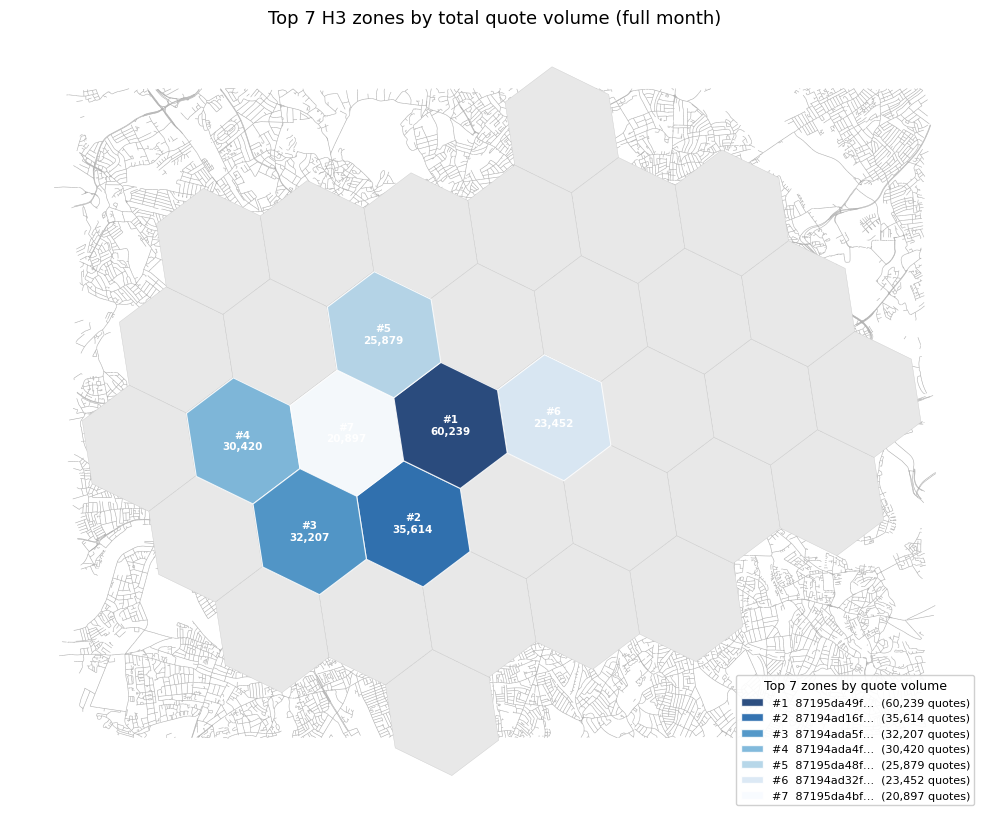

In [293]:
import matplotlib.patches as mpatches

# Top 7 zones by total quotes across the full month
top7 = (
    hourly_clean.groupby("h3_zone")["quote_count"]
    .sum()
    .nlargest(7)
    .reset_index(name="total_quotes")
    .reset_index(names="rank")
)
top7["rank"] += 1   # 1-indexed

print("Top 7 zones by total quote volume")
print("=" * 50)
for _, row in top7.iterrows():
    print(f"  #{int(row['rank'])}  {row.h3_zone}  —  {int(row.total_quotes):,} quotes")

# GeoDataFrames
background_gdf = zones_gdf.copy()
top7_gdf = zones_gdf.merge(top7, on="h3_zone")

roads_t7 = gpd.read_file(ROADS_FILE).to_crs("EPSG:4326")
bb = zones_gdf.total_bounds
roads_t7 = roads_t7.cx[bb[0]:bb[2], bb[1]:bb[3]]

cmap_top7 = plt.cm.Blues_r
norm_top7  = plt.Normalize(vmin=1, vmax=7)

fig, ax = plt.subplots(figsize=(10, 10))
roads_t7.plot(ax=ax, color="#aaaaaa", linewidth=0.4, zorder=1)
background_gdf.plot(ax=ax, color="#e8e8e8", edgecolor="#cccccc", linewidth=0.3, zorder=2)

for _, row in top7_gdf.iterrows():
    color = cmap_top7(norm_top7(row["rank"]))
    gpd.GeoDataFrame([row], geometry="geometry", crs="EPSG:4326").plot(
        ax=ax, color=color, edgecolor="white", linewidth=0.8, alpha=0.85, zorder=3,
    )
    cx, cy = row.geometry.centroid.x, row.geometry.centroid.y
    ax.annotate(
        f"#{int(row['rank'])}\n{int(row['total_quotes']):,}",
        xy=(cx, cy), fontsize=7.5, ha="center", va="center",
        fontweight="bold", color="white", zorder=4,
    )

legend_handles = [
    mpatches.Patch(
        facecolor=cmap_top7(norm_top7(row["rank"])),
        edgecolor="white", alpha=0.85,
        label=f"#{int(row['rank'])}  {row.h3_zone[:10]}…  ({int(row.total_quotes):,} quotes)",
    )
    for _, row in top7_gdf.sort_values("rank").iterrows()
]
ax.legend(
    handles=legend_handles, loc="lower right", fontsize=8,
    title="Top 7 zones by quote volume", title_fontsize=9, framealpha=0.92,
)
ax.set_title("Top 7 H3 zones by total quote volume (full month)", fontsize=13)
ax.set_axis_off()
plt.tight_layout()
plt.show()

In [296]:
top7_share = (
    hourly_clean.groupby("h3_zone")["quote_count"].sum().nlargest(7).sum()
    / hourly_clean.groupby("h3_zone")["quote_count"].sum().sum()
)
print(f"Top 7 zones by total quote volume take {top7_share:.1%} of all quotes")

Top 7 zones by total quote volume take 47.6% of all quotes


## 13. Hourly quote patterns by zone

For each zone: total quotes by hour across **all days**, **workdays (Mon–Fri)**, and **weekends (Sat–Sun)**.
Top 7 zones by volume first, then the remaining zones.

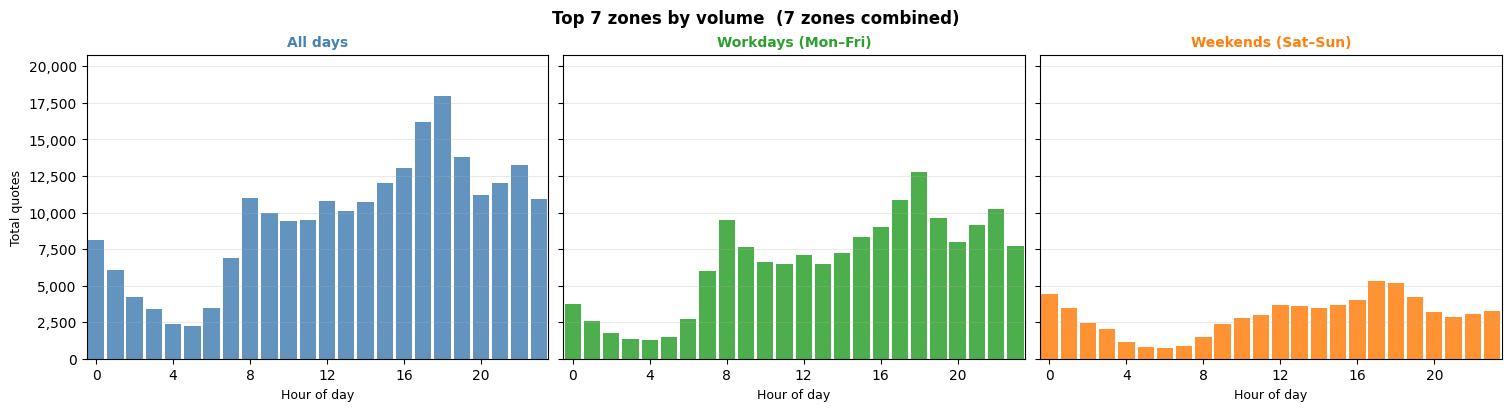

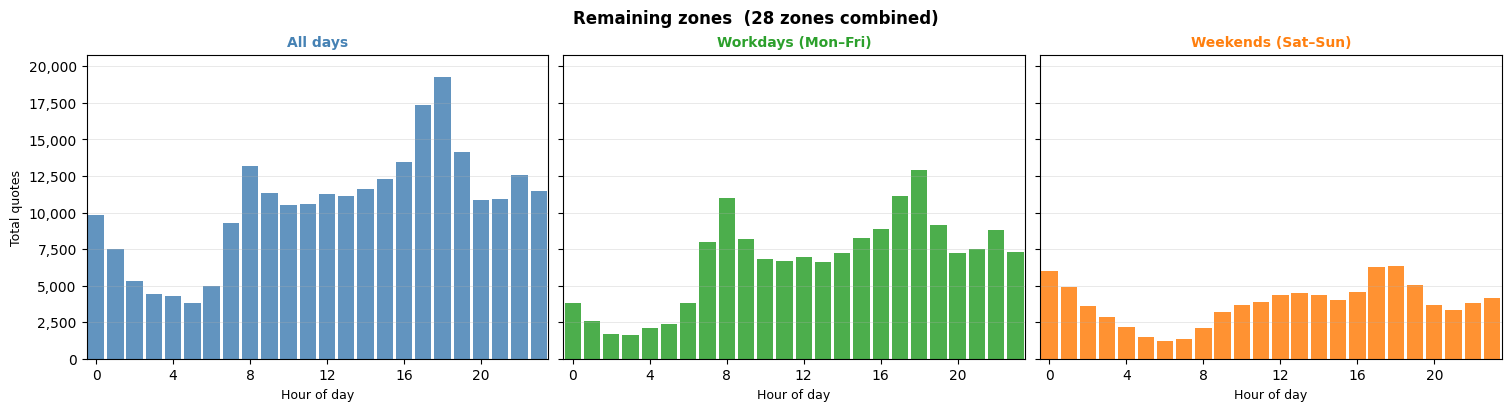

In [294]:
# ── Zone groups ───────────────────────────────────────────────────────────────
_zone_totals = (
    hourly_clean.groupby("h3_zone")["quote_count"].sum()
    .nlargest(7).reset_index(name="total_quotes")
)
top7_zones  = _zone_totals["h3_zone"].tolist()
other_zones = [z for z in zones_to_keep if z not in top7_zones]

# ── Sum all zones in a group, then split by day type ─────────────────────────
def group_hourly_totals(zone_list):
    """Aggregate quote counts across ALL zones in the list, per hour."""
    gdf = hourly_clean[hourly_clean["h3_zone"].isin(zone_list)].copy()
    wd  = gdf["day_of_week"].between(0, 4)
    all_days = gdf.groupby("hour_of_day")["quote_count"].sum().reindex(range(24), fill_value=0)
    workdays = gdf[wd].groupby("hour_of_day")["quote_count"].sum().reindex(range(24), fill_value=0)
    weekends = gdf[~wd].groupby("hour_of_day")["quote_count"].sum().reindex(range(24), fill_value=0)
    return all_days, workdays, weekends

totals_top7  = group_hourly_totals(top7_zones)
totals_other = group_hourly_totals(other_zones)

# Shared y-axis maximum across both groups and all 3 panels
y_max = max(s.max() for group in (totals_top7, totals_other) for s in group) * 1.08

# ── Plot helper ───────────────────────────────────────────────────────────────
PANEL_LABELS = ["All days", "Workdays (Mon–Fri)", "Weekends (Sat–Sun)"]
PANEL_COLORS = ["steelblue", "#2ca02c", "#ff7f0e"]

def plot_group(totals, suptitle, n_zones):
    fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True, constrained_layout=True)
    for ax, data, label, color in zip(axes, totals, PANEL_LABELS, PANEL_COLORS):
        ax.bar(range(24), data.values, color=color, alpha=0.85, width=0.85)
        ax.set_xlim(-0.5, 23.5)
        ax.set_ylim(0, y_max)
        ax.set_xticks(range(0, 24, 4))
        ax.set_xlabel("Hour of day", fontsize=9)
        ax.set_title(label, fontsize=10, fontweight="bold", color=color)
        ax.yaxis.set_major_formatter(
            plt.matplotlib.ticker.FuncFormatter(lambda x, _: f"{int(x):,}")
        )
        ax.grid(axis="y", linewidth=0.4, alpha=0.5)
    axes[0].set_ylabel("Total quotes", fontsize=9)
    fig.suptitle(f"{suptitle}  ({n_zones} zones combined)", fontsize=12, fontweight="bold")
    plt.show()

plot_group(totals_top7,  "Top 7 zones by volume",   len(top7_zones))
plot_group(totals_other, "Remaining zones",          len(other_zones))


## 14. Hourly quote patterns — per-zone average

Same as §17 but each group's total is divided by its number of zones,
so the two groups are directly comparable regardless of size.

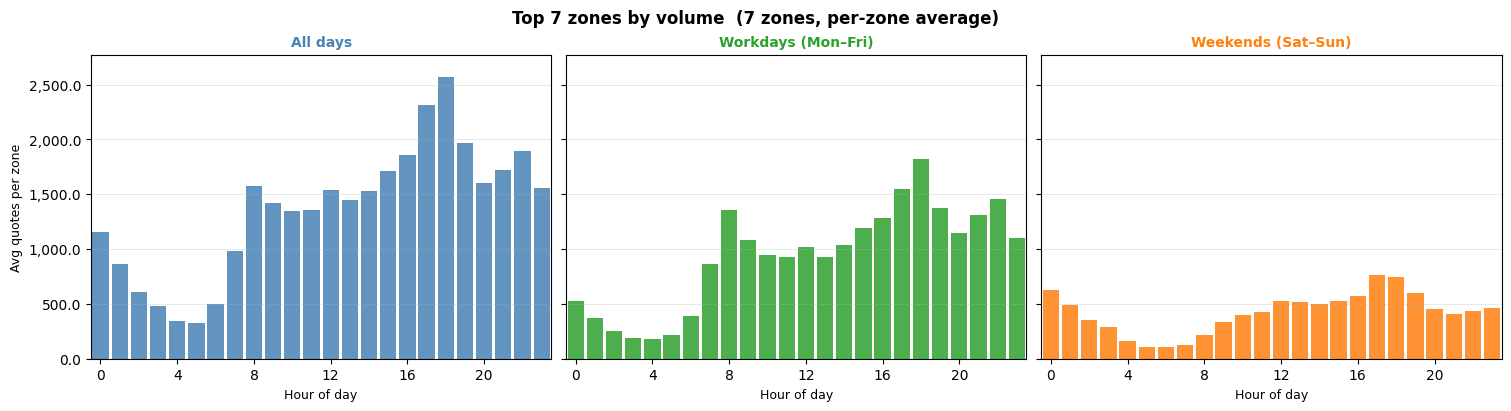

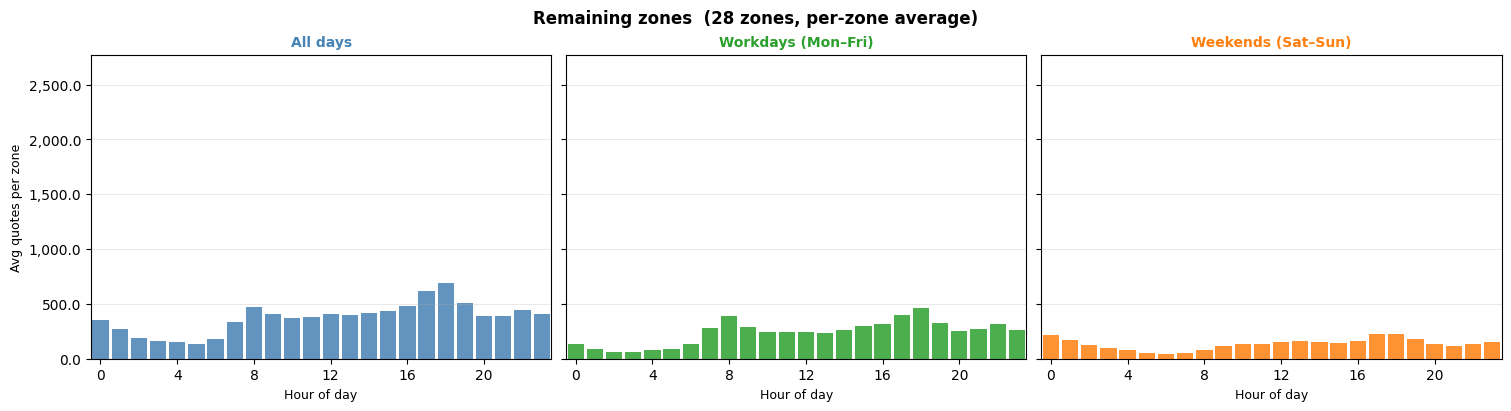

In [295]:
# Divide each group's hourly totals by its number of zones → avg quotes per zone
avg_top7  = tuple(s / len(top7_zones)  for s in totals_top7)
avg_other = tuple(s / len(other_zones) for s in totals_other)

# Shared y-max across both groups and all 3 panels
y_max_avg = max(s.max() for group in (avg_top7, avg_other) for s in group) * 1.08

def plot_group_avg(totals_avg, suptitle, n_zones):
    fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True, constrained_layout=True)
    for ax, data, label, color in zip(axes, totals_avg, PANEL_LABELS, PANEL_COLORS):
        ax.bar(range(24), data.values, color=color, alpha=0.85, width=0.85)
        ax.set_xlim(-0.5, 23.5)
        ax.set_ylim(0, y_max_avg)
        ax.set_xticks(range(0, 24, 4))
        ax.set_xlabel("Hour of day", fontsize=9)
        ax.set_title(label, fontsize=10, fontweight="bold", color=color)
        ax.yaxis.set_major_formatter(
            plt.matplotlib.ticker.FuncFormatter(lambda x, _: f"{x:,.1f}")
        )
        ax.grid(axis="y", linewidth=0.4, alpha=0.5)
    axes[0].set_ylabel("Avg quotes per zone", fontsize=9)
    fig.suptitle(f"{suptitle}  ({n_zones} zones, per-zone average)", fontsize=12, fontweight="bold")
    plt.show()

plot_group_avg(avg_top7,  "Top 7 zones by volume",  len(top7_zones))
plot_group_avg(avg_other, "Remaining zones",         len(other_zones))
